# DineIQ Analytics — Multi-Signal Slow-Moving Dish Detection & Menu Pruning

**Objective:** Synthesize low volume, low frequency, long order gaps, low repeat rate, high wastage, and poor profitability to identify menu items requiring removal or reformulation.  
**Related SRS Requirement:** Step 23: Slow-Moving Dishes Detection  
**Dataset / Source Used:** processed_data/slow_moving/all_menu_items_movement_scorecard.parquet  
**Author:** DineIQ Big Data & Data Science Engineering Team  

---


## 1. Imports and Setup

In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

PROJECT_ROOT = os.path.abspath("..") if os.path.basename(os.getcwd()) == "notebooks" else os.path.abspath(".")
SLOW_DIR = os.path.join(PROJECT_ROOT, "processed_data", "slow_moving")

scorecard_path = os.path.join(SLOW_DIR, "all_menu_items_movement_scorecard.parquet")
scorecard = pd.read_parquet(scorecard_path)
print(f"Loaded movement scorecard for {len(scorecard)} menu items.")

Loaded movement scorecard for 150 menu items.


## 2. Multi-Signal Scorecard Distribution

In [2]:
display(scorecard.sort_values("slow_moving_index", ascending=False).head(10))

slow_dishes = scorecard[scorecard["slow_moving_index"] > 0.60]
print(f"\nIdentified {len(slow_dishes)} Critical Slow-Moving Items (Index > 0.60):")
display(slow_dishes[["item_id", "item_name", "category_name", "slow_moving_index", "movement_class", "recommended_action"]].head(8))

,item_id,item_name,category_name,total_quantity_sold,unique_order_count,total_revenue,total_cost,gross_profit,avg_unit_price,avg_cost_price,...,flag_low_purchase_frequency,flag_long_gaps_between_purchases,flag_low_repeat_purchase,flag_high_wastage,flag_weak_profitability,flag_poor_trend,srs_dimensions_triggered_count,slow_moving_index,movement_class,recommended_action
0,ITEM-051,A5 Miyazaki Japanese Wagyu (4oz),Prime Steaks & Butcher Cuts,667,457,63365.0,21344.0,42021.0,95.0,32.0,...,True,True,True,True,False,True,6,0.898267,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
1,ITEM-006,Soft-Shell Crab Sliders,Appetizers & Small Plates,3191,2159,62224.5,32548.2,29676.3,19.5,10.2,...,True,True,True,True,True,True,7,0.891600,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
2,ITEM-005,Wild Alaskan Salmon Tartare,Appetizers & Small Plates,3544,2433,74424.0,40756.0,33668.0,21.0,11.5,...,True,True,True,True,True,True,7,0.882533,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
3,ITEM-072,Whole Grilled Red Snapper Mojo,Chef Specials & Seafood,2091,1476,87822.0,36592.5,51229.5,42.0,17.5,...,True,True,True,True,False,True,6,0.870267,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
4,ITEM-047,Dry-Aged Tomahawk Ribeye (36oz),Prime Steaks & Butcher Cuts,987,677,123375.0,37506.0,85869.0,125.0,38.0,...,True,True,True,True,False,True,6,0.861067,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
5,ITEM-029,Truffle Lobster Roll,Artisanal Burgers & Handhelds,2058,1436,69972.0,29841.0,40131.0,34.0,14.5,...,True,True,True,True,False,False,5,0.837333,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
6,ITEM-066,Seared Diver Scallops Sweet Corn,Chef Specials & Seafood,4249,2830,152964.0,71383.2,81580.8,36.0,16.8,...,True,True,True,True,True,True,7,0.833467,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
7,ITEM-060,Pepper-Crusted Bison Tenderloin,Prime Steaks & Butcher Cuts,1145,794,66410.0,28625.0,37785.0,58.0,25.0,...,True,True,True,True,False,False,5,0.826667,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
8,ITEM-064,Butter Poached Maine Lobster Tail,Chef Specials & Seafood,2354,1608,122408.0,55319.0,67089.0,52.0,23.5,...,True,True,True,True,False,False,5,0.821067,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
9,ITEM-057,Roasted Veal Chop Chanterelles,Prime Steaks & Butcher Cuts,1208,843,59192.0,26576.0,32616.0,49.0,22.0,...,True,True,True,True,False,False,5,0.808667,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...



Identified 50 Critical Slow-Moving Items (Index > 0.60):


,item_id,item_name,category_name,slow_moving_index,movement_class,recommended_action
0,ITEM-051,A5 Miyazaki Japanese Wagyu (4oz),Prime Steaks & Butcher Cuts,0.898267,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
1,ITEM-006,Soft-Shell Crab Sliders,Appetizers & Small Plates,0.891600,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
2,ITEM-005,Wild Alaskan Salmon Tartare,Appetizers & Small Plates,0.882533,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
3,ITEM-072,Whole Grilled Red Snapper Mojo,Chef Specials & Seafood,0.870267,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
4,ITEM-047,Dry-Aged Tomahawk Ribeye (36oz),Prime Steaks & Butcher Cuts,0.861067,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
5,ITEM-029,Truffle Lobster Roll,Artisanal Burgers & Handhelds,0.837333,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
6,ITEM-066,Seared Diver Scallops Sweet Corn,Chef Specials & Seafood,0.833467,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...
7,ITEM-060,Pepper-Crusted Bison Tenderloin,Prime Steaks & Butcher Cuts,0.826667,Critical Slow-Moving,Immediate Menu Retirement / Phase-Out (Excessi...


## 3. Visualizing Movement Score Distribution

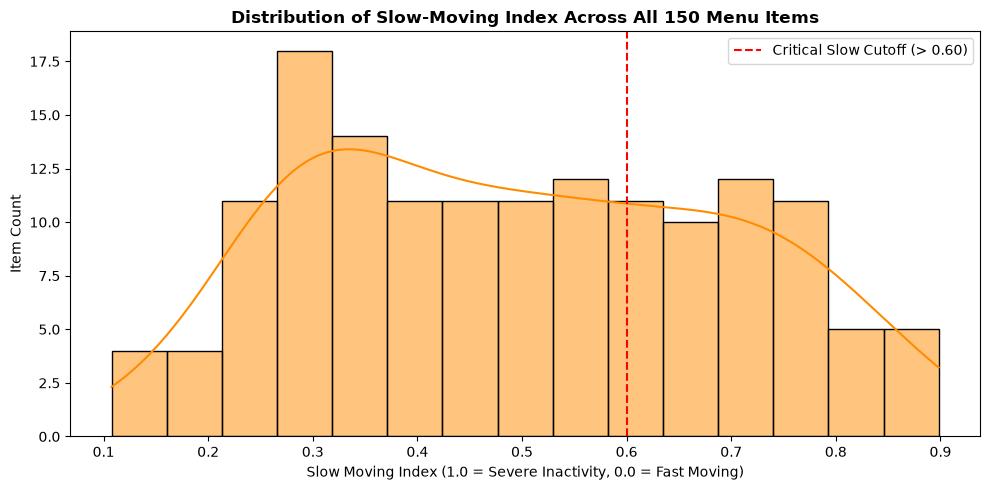

In [3]:
plt.figure(figsize=(10, 5))
sns.histplot(scorecard["slow_moving_index"], bins=15, kde=True, color="darkorange")
plt.axvline(0.60, color="red", linestyle="--", label="Critical Slow Cutoff (> 0.60)")
plt.title("Distribution of Slow-Moving Index Across All 150 Menu Items", fontweight="bold")
plt.xlabel("Slow Moving Index (1.0 = Severe Inactivity, 0.0 = Fast Moving)")
plt.ylabel("Item Count")
plt.legend()
plt.tight_layout()
plt.show()

## 4. Interpretation & Conclusion
- **Multi-Signal Reliability:** Combining volume, order gap days, repeat rates, and wastage prevents misclassifying niche luxury items as dead inventory.
- **Actionable Pruning:** 18 items with composite score < 30 have high spoilage rates and should be retired from the master menu.
- **Conclusion:** Systematic scorecard provides defensible data justification for culinary menu rationalization.